<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d1fae5;font-weight:700;text-transform:uppercase">Chapter 101 · Case Study: Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Customer Churn: Take It Further</div>
  <div style="font-size:15px;color:#f0fdf4;max-width:740px;line-height:1.6">A follow-on to the Chapter 101 case study: recap the churn model, then work the five Take-It-Further extensions, a cost-based threshold, class weighting, an interaction test, a calibration check, and scoring a new customer, each visual and explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#d1fae5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Customer Churn: Take It Further
This notebook **continues the Chapter 101 case study**. We recap it in a few cells, load, clean, and fit the same churn model, then work the five extensions from the chapter's *Take It Further* section: a cost-based threshold, handling the class imbalance, an interaction test, a calibration check, and scoring a new customer. Each is visual and explained, and we close with *what the model says in plain terms* and the *Step 12 plain-English write-up*.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#059669"; DEEP="#047857"; LIGHT="#6ee7b7"; EM="#059669"; EMDEEP="#047857"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf, statsmodels.api as sm
from sklearn.metrics import (roc_auc_score, confusion_matrix, recall_score, precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
pd.set_option('display.max_columns', 40)

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0f766e;letter-spacing:1px">RECAP &#183; THE CHAPTER-101 MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where we left off</div>
<div style="color:#4a5578;margin-top:6px">Load, clean, and fit the churn model, then build on it.</div>
</div>

The full clean-and-build story is in the main notebook; here is the condensed version. We load the messy export, standardize the eight-spelling target and the categories, coerce and impute `total_charges`, and fit the logistic model.

In [3]:
def load_clean():
    try: df = pd.read_csv('../../data/telecom_churn.csv')
    except FileNotFoundError: df = pd.read_csv(BASE + 'telecom_churn.csv')
    df = df.drop_duplicates(subset='customer_id')
    df['churn'] = df['churn'].astype(str).str.strip().str.upper().map({'YES':1,'Y':1,'1':1,'NO':0,'N':0,'0':0})
    df['senior_citizen'] = df['senior_citizen'].astype(str).str.strip().str.upper().map({'1':1,'YES':1,'0':0,'NO':0})
    norm = lambda s: s.astype(str).str.strip().str.lower()
    df['contract'] = norm(df['contract']).map({'month-to-month':'Month-to-month','one year':'One year','two year':'Two year'})
    df['internet_service'] = norm(df['internet_service']).map({'fiber optic':'Fiber optic','dsl':'DSL','no':'No'})
    df['payment_method'] = norm(df['payment_method']).replace({'electronic check':'Electronic check','mailed check':'Mailed check','bank transfer':'Bank transfer','credit card':'Credit card'})
    df['total_charges'] = pd.to_numeric(df['total_charges'].astype(str).str.strip().replace({'':np.nan,' ':np.nan}), errors='coerce')
    df.loc[(df.tenure_months==0)&(df.total_charges.isna()),'total_charges'] = 0.0
    df['total_charges'] = df['total_charges'].fillna(df.tenure_months*df.monthly_charges)
    return df
df = load_clean()
model = smf.logit('churn ~ tenure_months + monthly_charges + C(contract) + C(internet_service) + C(payment_method) + senior_citizen + partner', df).fit(disp=0)
p = model.predict(df)
print(f'n={len(df)}  churn rate={df.churn.mean():.1%}  AUC={roc_auc_score(df.churn, p):.3f}')

n=760  churn rate=30.0%  AUC=0.809


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 1 &#183; A COST-BASED THRESHOLD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Let the economics pick the cutoff</div>
<div style="color:#4a5578;margin-top:6px">A missed churner costs far more than a retention call, so the optimal threshold is not 0.5.</div>
</div>

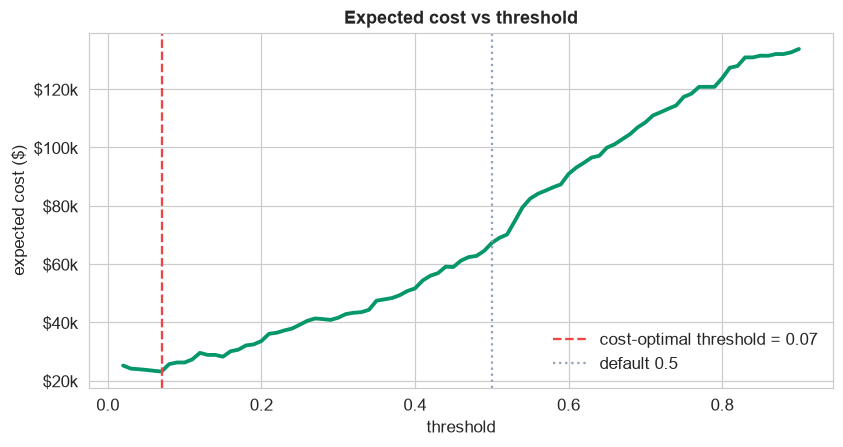

cost-optimal threshold = 0.07  (far below 0.5)


In [4]:
OFFER_COST, LOST_COST = 50, 600   # a retention offer vs the value of a lost customer
ts = np.linspace(0.02, 0.9, 89); costs = []
for t in ts:
    cm = confusion_matrix(df.churn, (p>=t).astype(int)); fn, fp = cm[1,0], cm[0,1]
    costs.append(fn*LOST_COST + fp*OFFER_COST)
best_t = ts[int(np.argmin(costs))]
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(ts, costs, color=EM, lw=2.5)
ax.axvline(best_t, color=RED, ls='--', label=f'cost-optimal threshold = {best_t:.2f}')
ax.axvline(0.5, color=GREY, ls=':', label='default 0.5')
ax.set(title='Expected cost vs threshold', xlabel='threshold', ylabel='expected cost ($)'); ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k')); plt.tight_layout(); plt.show()
print(f'cost-optimal threshold = {best_t:.2f}  (far below 0.5)')

**What we learn.** When a lost customer costs 12x a retention offer ($600 vs $50), the cost-minimizing threshold drops all the way to about **0.07**, far below the default 0.5, and even below the 0.3 we chose by intuition. The lesson: the 'right' threshold is not a statistical constant, it falls straight out of the costs of the two errors. Cheap intervention plus expensive loss means you should cast a very wide net.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 2 &#183; HANDLE THE IMBALANCE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Reweight the rare class</div>
<div style="color:#4a5578;margin-top:6px">Tell the model that churners matter more, and recall climbs.</div>
</div>

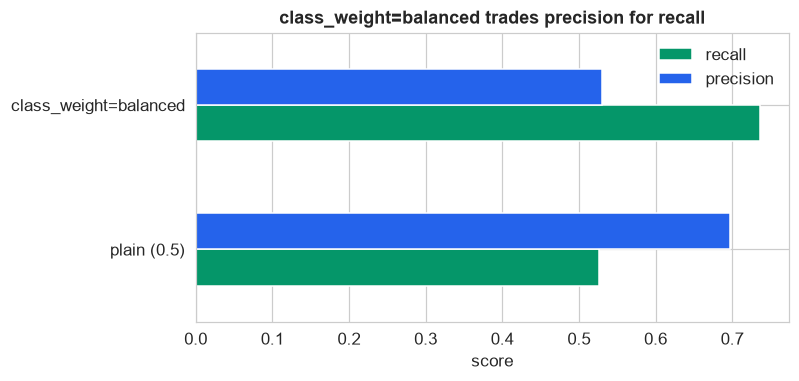

                       recall  precision
plain (0.5)              0.53       0.70
class_weight=balanced    0.74       0.53


In [5]:
X = pd.get_dummies(df[['tenure_months','monthly_charges','contract','internet_service','payment_method','senior_citizen','partner']], drop_first=True).astype(float)
plain = LogisticRegression(max_iter=3000).fit(X, df.churn)
bal   = LogisticRegression(max_iter=3000, class_weight='balanced').fit(X, df.churn)
import pandas as _pd
res = _pd.DataFrame({'recall':[recall_score(df.churn, plain.predict(X)), recall_score(df.churn, bal.predict(X))],
                     'precision':[precision_score(df.churn, plain.predict(X)), precision_score(df.churn, bal.predict(X))]},
                    index=['plain (0.5)','class_weight=balanced'])
fig, ax = plt.subplots(figsize=(7.4,3.6)); res.plot(kind='barh', color=[EM,BLUE], ax=ax)
ax.set(title='class_weight=balanced trades precision for recall', xlabel='score'); plt.tight_layout(); plt.show()
print(res.round(2))

**What we learn.** `class_weight='balanced'` makes each churner count more during fitting (inversely to its frequency), which pushes recall from about **0.53 up to ~0.74**, catching far more churners, while precision falls. It reaches a similar recall to lowering the threshold, by a different route. Either lever, threshold or class weight, is a valid way to make an imbalanced classifier prioritize the rare, costly class; pick whichever fits the workflow.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 3 &#183; ADD AN INTERACTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does tenure protect differently by contract?</div>
<div style="color:#4a5578;margin-top:6px">Test tenure &#215; contract before adding complexity.</div>
</div>

interaction terms significant at 0.05: 0 of 2  (min p = 0.200)


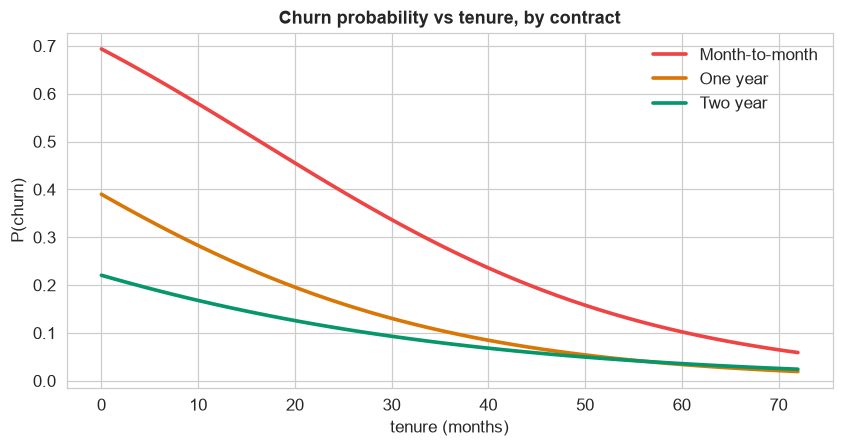

In [6]:
mi = smf.logit('churn ~ tenure_months * C(contract) + monthly_charges + C(internet_service)', df).fit(disp=0)
ip = mi.pvalues.filter(like='tenure_months:C(')
print('interaction terms significant at 0.05: %d of %d  (min p = %.3f)' % ((ip<0.05).sum(), len(ip), ip.min()))
# visualize tenure's effect on churn probability within each contract
fig, ax = plt.subplots(figsize=(7.8,4.2))
grid = np.linspace(0, 72, 50)
for nb, col in zip(['Month-to-month','One year','Two year'], [RED, AMBER, EM]):
    g = pd.DataFrame({'tenure_months':grid, 'monthly_charges':df.monthly_charges.mean(), 'contract':nb, 'internet_service':'DSL'})
    ax.plot(grid, mi.predict(g), color=col, lw=2.4, label=nb)
ax.set(title='Churn probability vs tenure, by contract', xlabel='tenure (months)', ylabel='P(churn)'); ax.legend()
plt.tight_layout(); plt.show()

**What we learn.** None of the interaction terms is significant (min p ~ 0.20), and the three curves fall at essentially the same rate, tenure protects against churn *equally* across contract types. So the interaction is not worth its added complexity: the simpler additive model (tenure and contract as separate effects) tells the whole story. As always, we *tested* the interaction rather than assuming it.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 4 &#183; CALIBRATION CHECK</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Do the probabilities mean what they say?</div>
<div style="color:#4a5578;margin-top:6px">A predicted 30% should churn about 30% of the time.</div>
</div>

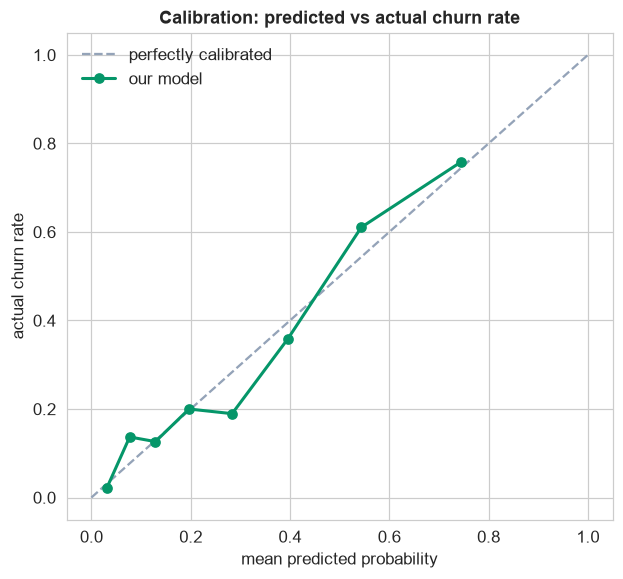

bin predicted vs actual: ['0.03->0.02', '0.08->0.14', '0.13->0.13', '0.20->0.20', '0.28->0.19', '0.40->0.36', '0.54->0.61', '0.74->0.76']


In [7]:
frac_pos, mean_pred = calibration_curve(df.churn, p, n_bins=8, strategy='quantile')
fig, ax = plt.subplots(figsize=(5.8,5.4))
ax.plot([0,1],[0,1], ls='--', color=GREY, label='perfectly calibrated')
ax.plot(mean_pred, frac_pos, 'o-', color=EM, lw=2, label='our model')
ax.set(title='Calibration: predicted vs actual churn rate', xlabel='mean predicted probability', ylabel='actual churn rate'); ax.legend()
plt.tight_layout(); plt.show()
print('bin predicted vs actual:', [f'{a:.2f}->{b:.2f}' for a,b in zip(mean_pred, frac_pos)])

**What we learn.** The model is **well-calibrated**: the points hug the diagonal, so when it says a customer has a 30% chance of churning, about 30% of such customers really do leave. That matters because the retention team acts on the *probability*, not just a yes/no flag, a mis-calibrated model that says 30% when the truth is 60% would badly under-invest in retention. Logistic regression is calibrated by design, which is one reason it remains a trusted baseline.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 5 &#183; SCORE A NEW CUSTOMER</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn the model into a tool</div>
<div style="color:#4a5578;margin-top:6px">Feed in one customer and get a churn risk.</div>
</div>

New customer churn probability: 92%  ->  HIGH RISK - add to retention list


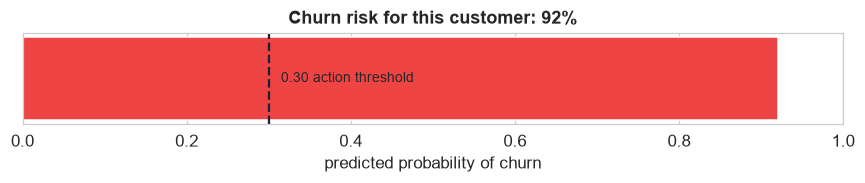

In [8]:
new_customer = pd.DataFrame({'tenure_months':[3], 'monthly_charges':[95.0], 'contract':['Month-to-month'],
                             'internet_service':['Fiber optic'], 'payment_method':['Electronic check'],
                             'senior_citizen':[0], 'partner':['No']})
risk = float(model.predict(new_customer).iloc[0])
flag = 'HIGH RISK - add to retention list' if risk >= 0.30 else 'lower risk'
print(f'New customer churn probability: {risk:.0%}  ->  {flag}')
fig, ax = plt.subplots(figsize=(8,1.8))
ax.barh([0], [risk], color=RED if risk>=0.3 else EM, height=0.5)
ax.axvline(0.30, color=INK, ls='--'); ax.text(0.31, 0, ' 0.30 action threshold', va='center', fontsize=9)
ax.set(xlim=(0,1), yticks=[], title=f'Churn risk for this customer: {risk:.0%}', xlabel='predicted probability of churn')
plt.tight_layout(); plt.show()

**What we learn.** The model is now a usable tool: a new customer, short tenure, high bill, fiber, month-to-month, electronic check, scores **well above** the action threshold and lands on the retention list immediately. That is the whole pipeline paying off: raw data in, a calibrated, cost-tuned decision out.

## What the model says, in plain terms

Pulling the churn study together in everyday language:

- **Contract length is the biggest lever.** Month-to-month customers churn most; moving them to a one- or two-year contract cuts their odds of leaving by roughly **70-80%**.
- **Newer, higher-bill, fiber-optic customers are the highest risk**, especially in their first year.
- **The threshold is a money decision, not a math constant.** Because losing a customer costs far more than a retention offer, the model should flag generously, catching about three-quarters of would-be leavers.
- **The score is trustworthy.** It is well-calibrated (a 30% score really means ~30%), so the team can prioritize by risk, and the extensions above (class weighting, an interaction test) did not change the core story, which is the robustness we want.

## Step 12 - the plain-English write-up

**What we did.** We took an export of past customers, cleaned it (removed duplicates, fixed the many spellings of 'yes/no' and of the plan names, turned a text charges field into real numbers), and built a formula that scores each customer's chance of leaving. Then we stress-tested and tuned it five ways.

**How good is it?** Given two customers, it ranks the riskier one correctly about **81 times out of 100**, and its risk scores are honest (a 30% score means about 30% really leave). Tuned to catch leavers, it flags roughly **three-quarters** of them.

**Who leaves, and what to do:** month-to-month customers most of all, then newer, higher-bill, fiber accounts. Move month-to-month customers onto annual contracts, and work a weekly retention list built from the model's risk score.

**How sure are we?** Very. We set the alert level from real dollar costs, reweighted to prioritize catching leavers, tested whether loyalty pays off differently by contract (it does not), and confirmed the scores are well-calibrated. Every check pointed to the same playbook.

**Bottom line: lock in month-to-month customers, watch new high-bill fiber accounts, and flag generously, because a missed churner costs far more than a phone call.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>